In [2]:
import os
import random
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.functional as TF

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from uno_vision.paths import SEGMENTER_MODELS_DIR
from uno_vision.segmentation_scene.data import collect_scene_pairs

SCENES_DIR = PROJECT_ROOT / "data" / "processed" / "game_snapshots"

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Project root:", PROJECT_ROOT)
print("Scene snapshots:", SCENES_DIR)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo
Scene snapshots: C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\data\processed\game_snapshots
torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER


In [3]:
# Build (image, mask) pairs from the processed game snapshots directory
pairs = collect_scene_pairs(scenes_dir=SCENES_DIR)

print(f"Total scene pairs: {len(pairs)}")
if len(pairs) == 0:
    raise RuntimeError(
        f"No scene pairs found in {SCENES_DIR}. "
        "Generate snapshots from notebooks/augmentations.ipynb first."
    )

train_pairs, val_pairs = train_test_split(
    pairs, test_size=0.15, random_state=SEED, shuffle=True
)
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

Total scene pairs: 500
Train: 425 | Val: 75


In [4]:
# Dataset — scene images are already full RGB JPEGs; masks are grayscale JPEGs
IMG_SIZE   = 256
BATCH_SIZE = 8


def letterbox(img, target_size=IMG_SIZE, fill=255, interpolation=Image.BILINEAR):
    w, h  = img.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    img   = img.resize((new_w, new_h), interpolation)
    pad_w = target_size - new_w
    pad_h = target_size - new_h
    padding = (pad_w // 2, pad_h // 2, pad_w - pad_w // 2, pad_h - pad_h // 2)
    return TF.pad(img, padding, fill=fill)


def preprocess_scene_pair(img_path, mask_path):
    img  = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    img  = letterbox(img,  IMG_SIZE, fill=255, interpolation=Image.BILINEAR)
    mask = letterbox(mask, IMG_SIZE, fill=0,   interpolation=Image.NEAREST)

    img_t = TF.to_tensor(img)
    img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    mask_arr = np.array(mask, dtype=np.float32) / 255.0
    mask_arr = (mask_arr > 0.5).astype(np.float32)
    mask_t   = torch.from_numpy(mask_arr).unsqueeze(0)

    return img_t, mask_t


class SceneSegDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.augment = augment
        print(f"  Pre-loading {len(pairs)} samples into RAM...", flush=True)
        self.data = []
        for i, (ip, mp) in enumerate(pairs):
            try:
                self.data.append(preprocess_scene_pair(ip, mp))
            except Exception as e:
                print(f"  [skip] {e}")
            if (i + 1) % 100 == 0:
                print(f"  {i + 1}/{len(pairs)} loaded", flush=True)
        print(f"  Done. {len(self.data)} samples ready.", flush=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_t, mask_t = self.data[idx]
        if self.augment:
            if random.random() < 0.5:
                img_t  = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t)
            if random.random() < 0.5:
                img_t  = TF.vflip(img_t)
                mask_t = TF.vflip(mask_t)
        return img_t, mask_t


train_ds = SceneSegDataset(train_pairs, augment=True)
val_ds   = SceneSegDataset(val_pairs,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

  Pre-loading 425 samples into RAM...
  100/425 loaded
  200/425 loaded
  300/425 loaded
  400/425 loaded
  Done. 425 samples ready.
  Pre-loading 75 samples into RAM...
  Done. 75 samples ready.
Train batches: 54 | Val batches: 10


In [5]:
# UNet architecture (must match the saved checkpoint exactly)
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)
        self.up3  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1  = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.out  = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs   = torch.sigmoid(logits).view(-1)
    targets = targets.view(-1)
    inter   = (probs * targets).sum()
    return 1.0 - (2.0 * inter + eps) / (probs.sum() + targets.sum() + eps)


def iou_score_from_logits(logits, targets, thresh=0.5, eps=1e-6):
    preds = (torch.sigmoid(logits) > thresh).float()
    inter = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3))
    return ((inter + eps) / (union + eps)).mean().item()


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNetSmall().to(device)
param_count = sum(param.numel() for param in model.parameters() if param.requires_grad)
assert param_count <= 12_000_000, f"UNetSmall has {param_count:,} trainable params, above the 12M cap."
print(f"[compliance] UNetSmall: {param_count:,} trainable params")

ckpt_path = SEGMENTER_MODELS_DIR / "scene_segmenter_unet_small.pth"
if ckpt_path.is_file():
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f"Loaded checkpoint: {ckpt_path}")
else:
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"No existing checkpoint at {ckpt_path}; training from scratch.")

bce       = nn.BCEWithLogitsLoss()
# Lower LR than original training to preserve learned features
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Using device: {device}")

[compliance] UNetSmall: 1,928,417 trainable params
No existing checkpoint at C:\Users\doria\Documents\EPFL\IA\iapr2026do\projodo\artifacts\models\segmenter\scene_segmenter_unet_small.pth; training from scratch.
Using device: cuda


In [6]:
# Fine-tuning loop
EPOCHS = 15

train_losses, val_losses = [], []
train_ious,   val_ious   = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = tr_iou = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = 0.5 * bce(logits, masks) + 0.5 * dice_loss_from_logits(logits, masks)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_iou  += iou_score_from_logits(logits.detach(), masks) * imgs.size(0)

    tr_loss /= len(train_ds)
    tr_iou  /= len(train_ds)

    model.eval()
    va_loss = va_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss   = 0.5 * bce(logits, masks) + 0.5 * dice_loss_from_logits(logits, masks)
            va_loss += loss.item() * imgs.size(0)
            va_iou  += iou_score_from_logits(logits, masks) * imgs.size(0)

    va_loss /= len(val_ds)
    va_iou  /= len(val_ds)

    train_losses.append(tr_loss);  val_losses.append(va_loss)
    train_ious.append(tr_iou);     val_ious.append(va_iou)
    scheduler.step()

    print(
        f"Epoch {epoch:2d}/{EPOCHS} | "
        f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | "
        f"train_iou={tr_iou:.4f} val_iou={va_iou:.4f}"
    )

# Overwrite the checkpoint with the fine-tuned weights
torch.save(model.state_dict(), ckpt_path)
print(f"Saved fine-tuned model: {ckpt_path}")

Epoch  1/15 | train_loss=0.5669 val_loss=0.4824 | train_iou=0.6672 val_iou=0.8132
Epoch  2/15 | train_loss=0.4673 val_loss=0.4604 | train_iou=0.8445 val_iou=0.8869
Epoch  3/15 | train_loss=0.4414 val_loss=0.4369 | train_iou=0.8687 val_iou=0.8844
Epoch  4/15 | train_loss=0.4214 val_loss=0.4195 | train_iou=0.8843 val_iou=0.8609
Epoch  5/15 | train_loss=0.4033 val_loss=0.4080 | train_iou=0.8965 val_iou=0.8627
Epoch  6/15 | train_loss=0.3895 val_loss=0.3954 | train_iou=0.9061 val_iou=0.9044
Epoch  7/15 | train_loss=0.3813 val_loss=0.3821 | train_iou=0.9104 val_iou=0.9157
Epoch  8/15 | train_loss=0.3726 val_loss=0.3777 | train_iou=0.9156 val_iou=0.9205
Epoch  9/15 | train_loss=0.3656 val_loss=0.3717 | train_iou=0.9167 val_iou=0.9212
Epoch 10/15 | train_loss=0.3582 val_loss=0.3621 | train_iou=0.9208 val_iou=0.9105
Epoch 11/15 | train_loss=0.3517 val_loss=0.3595 | train_iou=0.9252 val_iou=0.9147
Epoch 12/15 | train_loss=0.3480 val_loss=0.3560 | train_iou=0.9256 val_iou=0.9203
Epoch 13/15 | tr

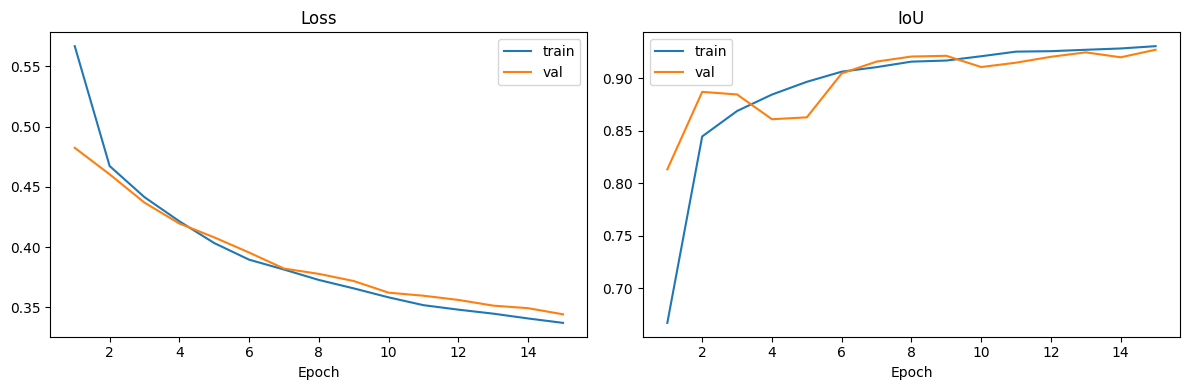

In [7]:
# Training curves
epochs_x = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, train_losses, label="train")
ax1.plot(epochs_x, val_losses,   label="val")
ax1.set_title("Loss");  ax1.set_xlabel("Epoch");  ax1.legend()

ax2.plot(epochs_x, train_ious, label="train")
ax2.plot(epochs_x, val_ious,   label="val")
ax2.set_title("IoU");  ax2.set_xlabel("Epoch");  ax2.legend()

plt.tight_layout()
plt.show()